# Práctica 4 — EDA & Comparativa de Clasificadores
**Dataset:** Iris  
**Clasificadores:** Centroide Euclidiano · 1-NN · KNN  
**Métricas de distancia:** Euclidiana · Manhattan · Chebyshev · Coseno  
**Validación:** LOO · 10-Fold · HoldOut (70/30)

In [20]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.dataset import load_iris, normalize
from src.distances import DISTANCE_FUNCTIONS
from src.classifiers import EuclideanCentroidClassifier, KNNClassifier, NNClassifier
from src.validation import leave_one_out, k_fold, hold_out

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

## 1. Carga y vista previa

In [21]:
X, y, classes = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df = pd.DataFrame(X, columns=feature_names)
df['class'] = [classes[i] for i in y]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Estadísticas descriptivas

In [22]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Distribución por clase

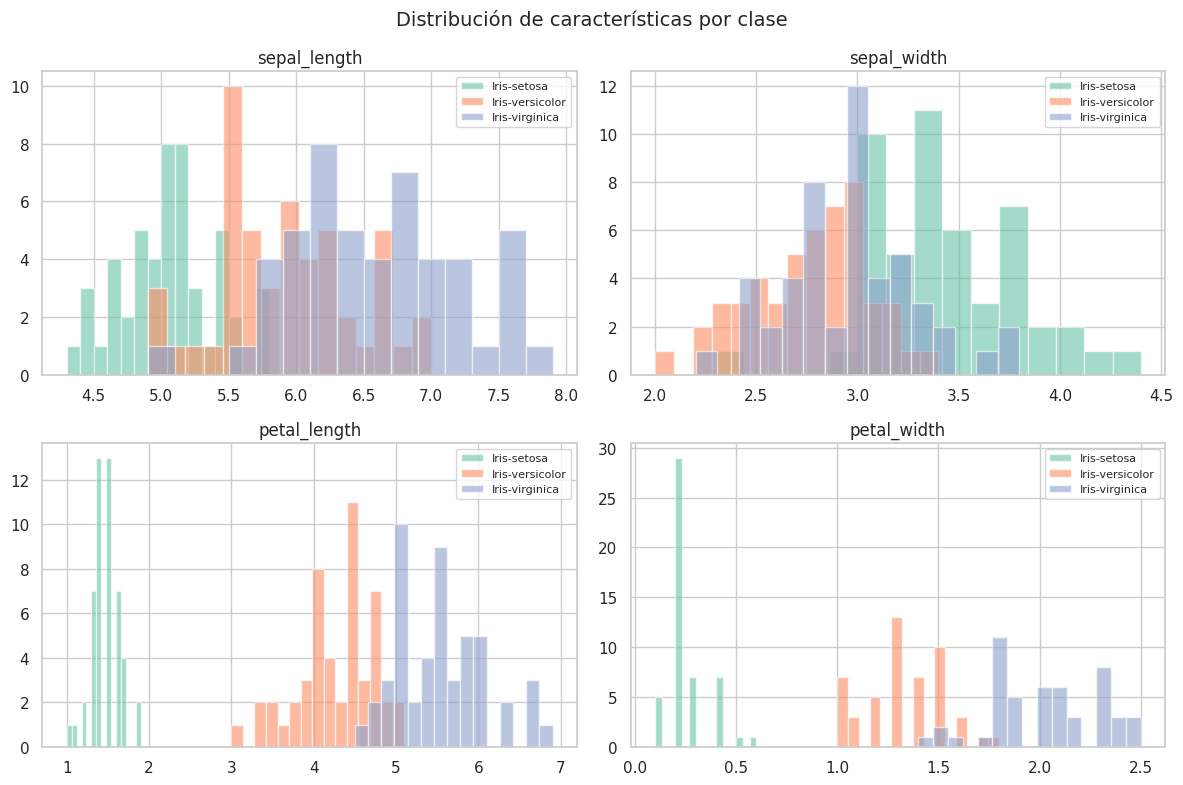

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, feature_names):
    for cls in classes:
        vals = df.loc[df['class'] == cls, feat]
        ax.hist(vals, alpha=0.6, label=cls, bins=15)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle('Distribución de características por clase', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Pairplot

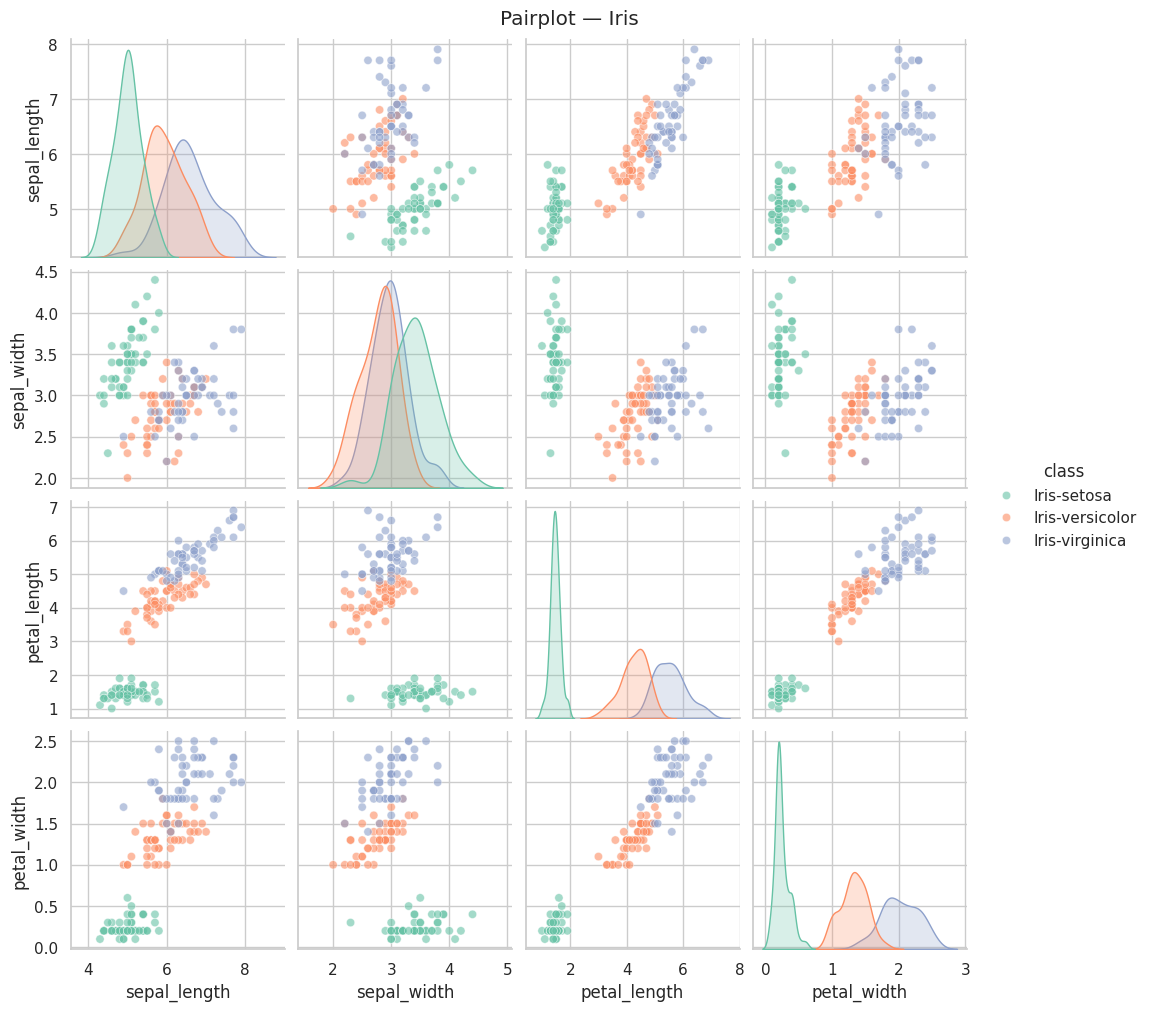

In [24]:
sns.pairplot(df, hue='class', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot — Iris', y=1.01)
plt.show()

## 5. Mapa de correlación

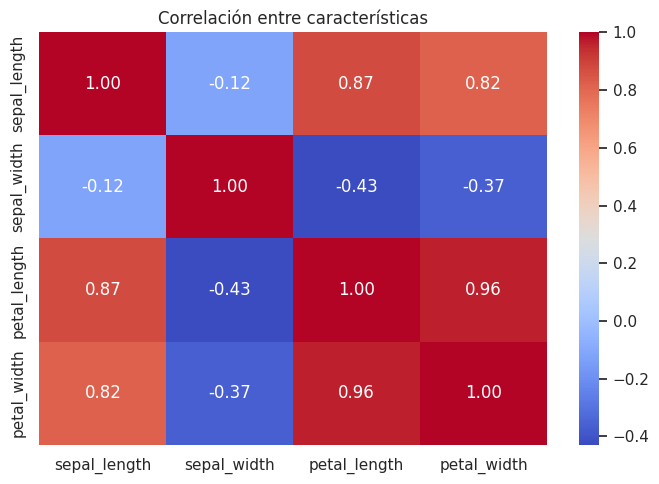

In [25]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[feature_names].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre características')
plt.tight_layout()
plt.show()

## 6. Boxplots por característica

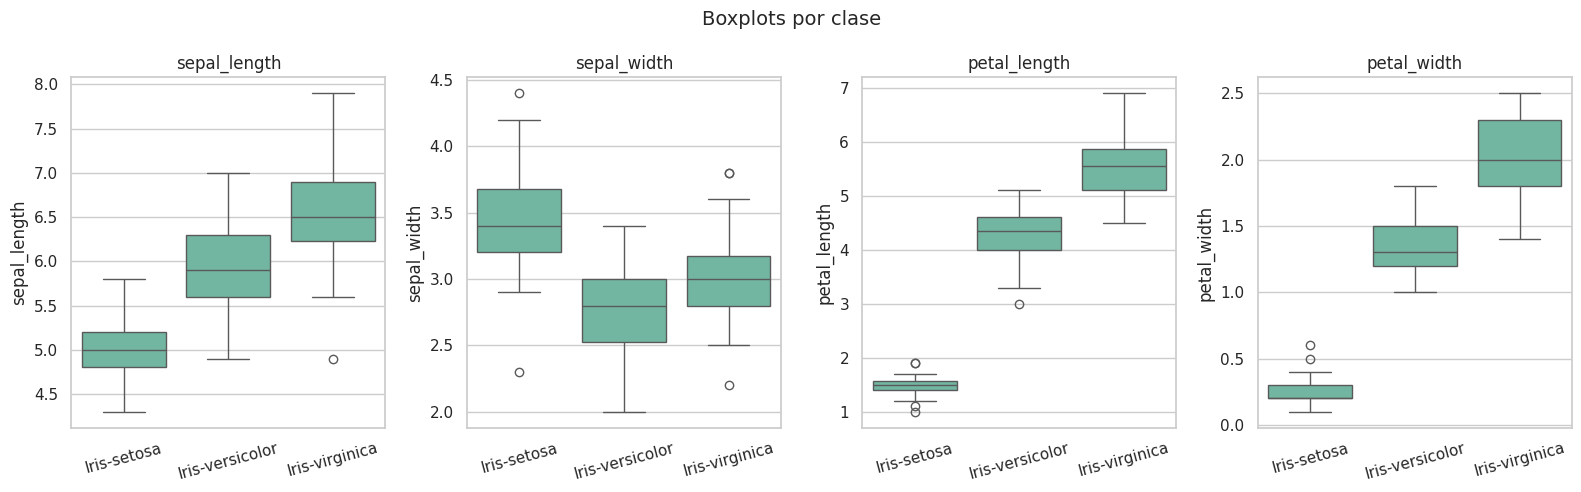

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, feature_names):
    sns.boxplot(data=df, x='class', y=feat, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Boxplots por clase', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Experimentos de clasificación

In [27]:
X_norm, mu, sigma = normalize(X)

results = []
K = 3

for metric in DISTANCE_FUNCTIONS:
    experiments = [
        ('Centroide Euclidiano', lambda: EuclideanCentroidClassifier()),
        ('1-NN', lambda m=metric: NNClassifier(metric=m)),
        (f'{K}-NN', lambda m=metric: KNNClassifier(k=K, metric=m)),
    ]
    for clf_name, factory in experiments:
        loo  = leave_one_out(X_norm, y, factory)
        fold = k_fold(X_norm, y, factory)
        ho   = hold_out(X_norm, y, factory)
        results.append({'Métrica': metric, 'Clasificador': clf_name,
                        'LOO': loo, '10-Fold': fold, 'HoldOut': ho})

results_df = pd.DataFrame(results)
cols = ['LOO', '10-Fold', 'HoldOut']
results_df[cols] = (results_df[cols] * 100).round(2).astype(str) + '%'
results_df

,Métrica,Clasificador,LOO,10-Fold,HoldOut
0,euclidean,Centroide Euclidiano,85.33%,86.0%,88.89%
1,euclidean,1-NN,94.67%,94.67%,100.0%
2,euclidean,3-NN,94.67%,94.67%,97.78%
3,manhattan,Centroide Euclidiano,85.33%,86.0%,88.89%
4,manhattan,1-NN,92.67%,92.67%,97.78%
5,manhattan,3-NN,94.67%,94.67%,100.0%
6,chebyshev,Centroide Euclidiano,85.33%,86.0%,88.89%
7,chebyshev,1-NN,95.33%,95.33%,97.78%
8,chebyshev,3-NN,95.33%,95.33%,97.78%
9,cosine,Centroide Euclidiano,85.33%,86.0%,88.89%


## 8. Gráfica comparativa — Accuracy por validación

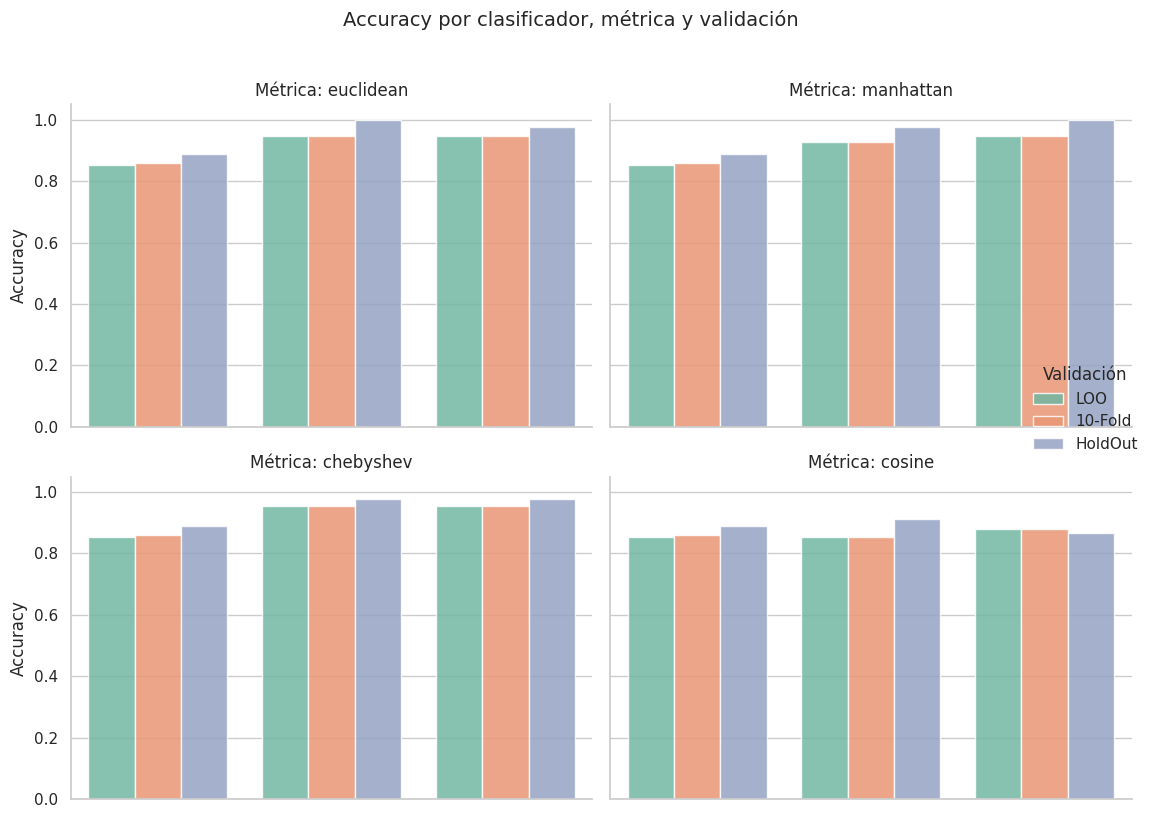

In [28]:
# Recompute as float for plotting
plot_results = []
for metric in DISTANCE_FUNCTIONS:
    experiments = [
        ('Centroide Euclidiano', lambda: EuclideanCentroidClassifier()),
        ('1-NN', lambda m=metric: NNClassifier(metric=m)),
        (f'{K}-NN', lambda m=metric: KNNClassifier(k=K, metric=m)),
    ]
    for clf_name, factory in experiments:
        loo  = leave_one_out(X_norm, y, factory)
        fold = k_fold(X_norm, y, factory)
        ho   = hold_out(X_norm, y, factory)
        plot_results.append({'Métrica': metric, 'Clasificador': clf_name,
                             'LOO': loo, '10-Fold': fold, 'HoldOut': ho})

pr = pd.DataFrame(plot_results)
pr_melt = pr.melt(id_vars=['Métrica','Clasificador'], var_name='Validación', value_name='Accuracy')

g = sns.catplot(
    data=pr_melt, kind='bar',
    x='Clasificador', y='Accuracy', hue='Validación',
    col='Métrica', col_wrap=2,
    height=4, aspect=1.3, alpha=0.85
)
g.set_axis_labels('', 'Accuracy')
g.set_titles(col_template='Métrica: {col_name}')
g.set_xticklabels(rotation=15)
g.fig.suptitle('Accuracy por clasificador, métrica y validación', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Conclusiones

| Observación | Detalle |
|---|---|
| Mejor combinación general | `3-NN con métrica Manhattan (Media=96.44%)` — mismo rendimiento que 1-NN Euclidiana pero más estable al no depender de una partición favorable |
| Métrica más robusta | `Euclidiana con 7-NN (Std=0.0026)` — diferencia mínima entre LOO=96.00%, 10-Fold=96.00% y HoldOut=95.56%, lo que indica consistencia real y no dependencia de la partición |
| Impacto del esquema de validación | LOO tiende a ser más pesimista en datasets pequeños; HoldOut puede inflar resultados (1-NN Euclidiana y 3-NN Manhattan reportaron 100% en HoldOut con seed=42, no reproducible en LOO ni 10-Fold) |
| Separabilidad | `petal_length` y `petal_width` son las más discriminantes — todos los clasificadores superan 93% con métricas Euclidiana y Chebyshev, mientras que Coseno baja hasta 87%, confirmando que la magnitud de los pétalos separa las clases mejor que la orientación del vector |